Instalar e importar librerías

In [1]:
!pip install transformers accelerate -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import pipeline

Generar dataset CSV sin normalizar

In [2]:
np.random.seed(42)

n = 1000

datos = pd.DataFrame({
    "edad": np.random.randint(18, 70, n),
    "ingresos_mensuales": np.random.randint(1500000, 12000000, n),
    "horas_redes_sociales": np.random.uniform(0, 8, n).round(2),
    "visitas_web": np.random.randint(0, 30, n),
    "genero": np.random.choice(["Masculino", "Femenino", "Otro"], n),
    "ciudad": np.random.choice(["Asunción", "San Lorenzo", "Luque", "Capiatá", "Fernando de la Mora"], n),
    "tipo_cliente": np.random.choice(["Nuevo", "Frecuente", "Premium"], n),
    "dispositivo": np.random.choice(["Celular", "Computadora", "Tablet"], n)
})

probabilidad_compra = (
    (datos["ingresos_mensuales"] > 5000000).astype(int) +
    (datos["visitas_web"] > 10).astype(int) +
    (datos["horas_redes_sociales"] > 3).astype(int) +
    (datos["tipo_cliente"] == "Premium").astype(int)
)

datos["compro"] = np.where(probabilidad_compra >= 2, 1, 0)

for columna in ["edad", "ingresos_mensuales", "horas_redes_sociales", "genero", "ciudad", "tipo_cliente"]:
    indices_nulos = np.random.choice(datos.index, size=40, replace=False)
    datos.loc[indices_nulos, columna] = np.nan

datos.to_csv("clientes_sin_normalizar.csv", index=False)

datos.head()

,edad,ingresos_mensuales,horas_redes_sociales,visitas_web,genero,ciudad,tipo_cliente,dispositivo,compro
0,56.0,7372354.0,7.61,9,Masculino,Capiatá,Premium,Celular,1
1,69.0,NaN,5.11,27,NaN,Fernando de la Mora,Premium,Tablet,1
2,NaN,11310404.0,6.94,4,Otro,Fernando de la Mora,Premium,Tablet,1
3,NaN,3819049.0,3.64,2,Masculino,San Lorenzo,Nuevo,Computadora,0
4,60.0,NaN,4.12,22,Masculino,San Lorenzo,Frecuente,Celular,1


Verificar datos faltantes

In [3]:
df = pd.read_csv("clientes_sin_normalizar.csv")

print("Tamaño del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nValores nulos por columna:")
print(df.isnull().sum())

Tamaño del dataset:
(1000, 9)

Primeras filas:


,edad,ingresos_mensuales,horas_redes_sociales,visitas_web,genero,ciudad,tipo_cliente,dispositivo,compro
0,56.0,7372354.0,7.61,9,Masculino,Capiatá,Premium,Celular,1
1,69.0,NaN,5.11,27,NaN,Fernando de la Mora,Premium,Tablet,1
2,NaN,11310404.0,6.94,4,Otro,Fernando de la Mora,Premium,Tablet,1
3,NaN,3819049.0,3.64,2,Masculino,San Lorenzo,Nuevo,Computadora,0
4,60.0,NaN,4.12,22,Masculino,San Lorenzo,Frecuente,Celular,1



Valores nulos por columna:
edad                    40
ingresos_mensuales      40
horas_redes_sociales    40
visitas_web              0
genero                  40
ciudad                  40
tipo_cliente            40
dispositivo              0
compro                   0
dtype: int64


AGENTE 1: Normalizador

In [4]:
class AgenteNormalizador:
    def __init__(self, target):
        self.target = target
        self.preprocesador = None

    def procesar(self, df):
        X = df.drop(columns=[self.target])
        y = df[self.target]

        columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
        columnas_categoricas = X.select_dtypes(include=["object"]).columns

        transformador_numerico = Pipeline(steps=[
            ("imputador", SimpleImputer(strategy="mean")),
            ("escalador", StandardScaler())
        ])

        transformador_categorico = Pipeline(steps=[
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificador", OneHotEncoder(handle_unknown="ignore"))
        ])

        self.preprocesador = ColumnTransformer(
            transformers=[
                ("numericas", transformador_numerico, columnas_numericas),
                ("categoricas", transformador_categorico, columnas_categoricas)
            ]
        )

        X_limpio = self.preprocesador.fit_transform(X)

        return X_limpio, y, columnas_numericas, columnas_categoricas

Ejecutar AGENTE 1

In [5]:
normalizador = AgenteNormalizador(target="compro")

X_limpio, y, columnas_numericas, columnas_categoricas = normalizador.procesar(df)

print("AGENTE 1 FINALIZADO")
print("Columnas numéricas:", list(columnas_numericas))
print("Columnas categóricas:", list(columnas_categoricas))
print("Tamaño del dataset limpio:", X_limpio.shape)

AGENTE 1 FINALIZADO
Columnas numéricas: ['edad', 'ingresos_mensuales', 'horas_redes_sociales', 'visitas_web']
Columnas categóricas: ['genero', 'ciudad', 'tipo_cliente', 'dispositivo']
Tamaño del dataset limpio: (1000, 18)


AGENTE 2: Entrenador

In [6]:
class AgenteEntrenador:
    def __init__(self):
        self.modelos = {
            "Regresión Logística": LogisticRegression(max_iter=1000),
            "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42)
        }

        self.resultados = {}
        self.mejor_modelo = None
        self.nombre_mejor_modelo = None
        self.X_test = None
        self.y_test = None

    def entrenar(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            random_state=42,
            stratify=y
        )

        self.X_test = X_test
        self.y_test = y_test

        for nombre, modelo in self.modelos.items():
            modelo.fit(X_train, y_train)

            predicciones = modelo.predict(X_test)

            self.resultados[nombre] = {
                "accuracy": accuracy_score(y_test, predicciones),
                "precision": precision_score(y_test, predicciones),
                "recall": recall_score(y_test, predicciones),
                "f1_score": f1_score(y_test, predicciones),
                "matriz_confusion": confusion_matrix(y_test, predicciones),
                "reporte": classification_report(y_test, predicciones)
            }

        self.nombre_mejor_modelo = max(
            self.resultados,
            key=lambda modelo: self.resultados[modelo]["f1_score"]
        )

        self.mejor_modelo = self.modelos[self.nombre_mejor_modelo]

        return self.resultados, self.nombre_mejor_modelo

Ejecutar AGENTE 2

In [7]:
entrenador = AgenteEntrenador()

resultados, mejor_modelo = entrenador.entrenar(X_limpio, y)

print("AGENTE 2 FINALIZADO")
print("Mejor modelo seleccionado:", mejor_modelo)

tabla_resultados = pd.DataFrame(resultados).T

display(tabla_resultados[["accuracy", "precision", "recall", "f1_score"]])

AGENTE 2 FINALIZADO
Mejor modelo seleccionado: Random Forest


,accuracy,precision,recall,f1_score
Regresión Logística,0.893333,0.918033,0.949153,0.933333
Árbol de Decisión,0.966667,0.97479,0.983051,0.978903
Random Forest,0.98,0.975207,1.0,0.987448


Gráfico de comparación de modelos

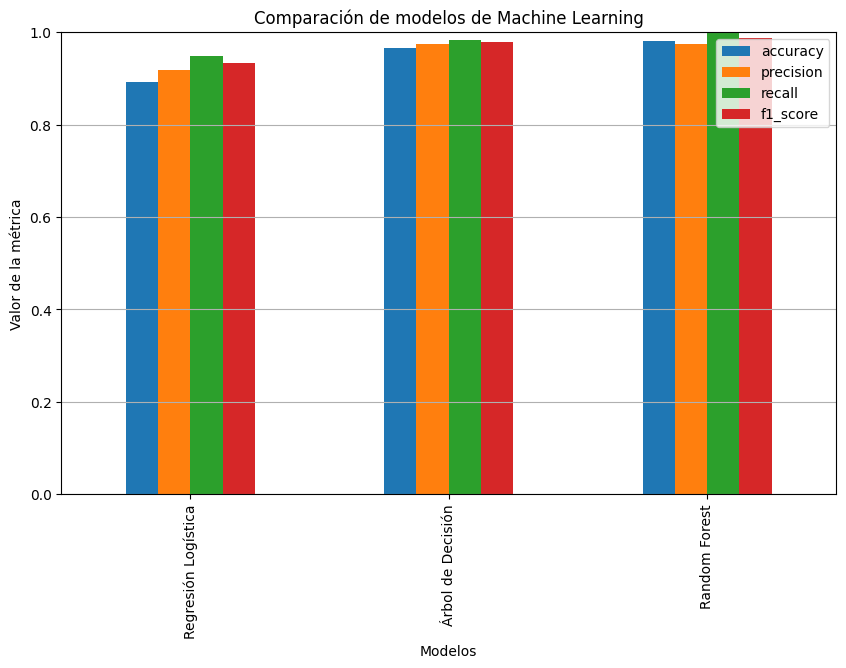

In [8]:
metricas = tabla_resultados[["accuracy", "precision", "recall", "f1_score"]]

metricas.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de modelos de Machine Learning")
plt.xlabel("Modelos")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

Ver matriz de confusión del mejor modelo

In [9]:
print("Mejor modelo:", mejor_modelo)

print("\nMatriz de confusión:")
print(resultados[mejor_modelo]["matriz_confusion"])

print("\nReporte de clasificación:")
print(resultados[mejor_modelo]["reporte"])

Mejor modelo: Random Forest

Matriz de confusión:
[[ 58   6]
 [  0 236]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        64
           1       0.98      1.00      0.99       236

    accuracy                           0.98       300
   macro avg       0.99      0.95      0.97       300
weighted avg       0.98      0.98      0.98       300



AGENTE 3: Comunicador

In [10]:
class AgenteComunicadorTransformer:
    def __init__(self):
        self.generador = pipeline(
            "text-generation",
            model="distilgpt2"
        )

    def generar_reporte(self, resultados, mejor_modelo, filas, columnas_numericas, columnas_categoricas):
        mejor = resultados[mejor_modelo]

        prompt = f"""
REPORTE ACADEMICO DE MACHINE LEARNING

Dataset:
Se trabajo con {filas} registros de clientes.
El objetivo fue predecir si un cliente compra o no un producto.

Agente 1 Normalizador:
- Limpio datos faltantes.
- Imputo valores nulos.
- Escalo variables numericas.
- Codifico variables categoricas.

Variables numericas:
{list(columnas_numericas)}

Variables categoricas:
{list(columnas_categoricas)}

Agente 2 Entrenador:
Se entrenaron varios modelos de clasificacion.
El mejor modelo fue {mejor_modelo}.

Metricas:
Accuracy: {mejor["accuracy"]:.4f}
Precision: {mejor["precision"]:.4f}
Recall: {mejor["recall"]:.4f}
F1 Score: {mejor["f1_score"]:.4f}

Conclusion:
"""

        respuesta = self.generador(
            prompt,
            max_new_tokens=180,
            do_sample=True,
            temperature=0.7,
            pad_token_id=50256
        )

        return respuesta[0]["generated_text"]

Ejecutar AGENTE 3

In [11]:
comunicador = AgenteComunicadorTransformer()

reporte_transformer = comunicador.generar_reporte(
    resultados=resultados,
    mejor_modelo=mejor_modelo,
    filas=df.shape[0],
    columnas_numericas=columnas_numericas,
    columnas_categoricas=columnas_categoricas
)

print(reporte_transformer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



REPORTE ACADEMICO DE MACHINE LEARNING

Dataset:
Se trabajo con 1000 registros de clientes.
El objetivo fue predecir si un cliente compra o no un producto.

Agente 1 Normalizador:
- Limpio datos faltantes.
- Imputo valores nulos.
- Escalo variables numericas.
- Codifico variables categoricas.

Variables numericas:
['edad', 'ingresos_mensuales', 'horas_redes_sociales', 'visitas_web']

Variables categoricas:
['genero', 'ciudad', 'tipo_cliente', 'dispositivo']

Agente 2 Entrenador:
Se entrenaron varios modelos de clasificacion.
El mejor modelo fue Random Forest.

Metricas:
Accuracy: 0.9800
Precision: 0.9752
Recall: 1.0000
F1 Score: 0.9874

Conclusion:
The above table lists the following values and the following values for each of the following values:
This table lists the following values and the following values for each of the following values:
This table lists the following values and the following values for each of the following values:
This table lists the following values and the f